# Titanic Survival Prediction

## Exploratory Data Analysis

Goal:
Understand the dataset and identify patterns associated with passenger survival.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving test.csv to test.csv
Saving train.csv to train.csv


In [3]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

print(train.shape)
print(test.shape)

(891, 12)
(418, 11)


In [4]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train.isnull().sum().sort_values(ascending=False)

,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


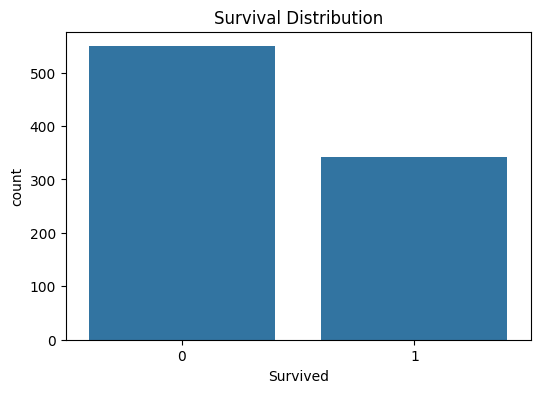

In [8]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="Survived"
)

plt.title("Survival Distribution")
plt.show()

In [9]:
survival_rate = train["Survived"].mean()

print(
    f"Survival Rate: {survival_rate:.2%}"
)

Survival Rate: 38.38%


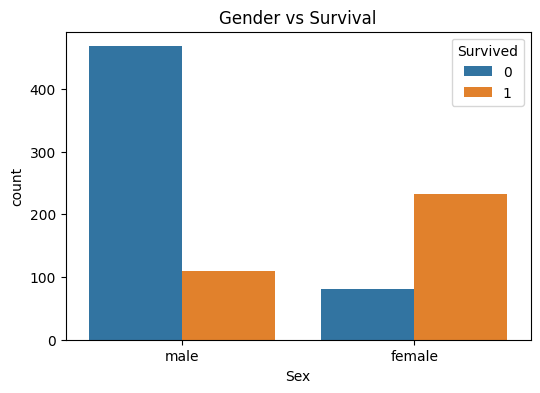

In [10]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=train,
    x="Sex",
    hue="Survived"
)

plt.title("Gender vs Survival")
plt.show()

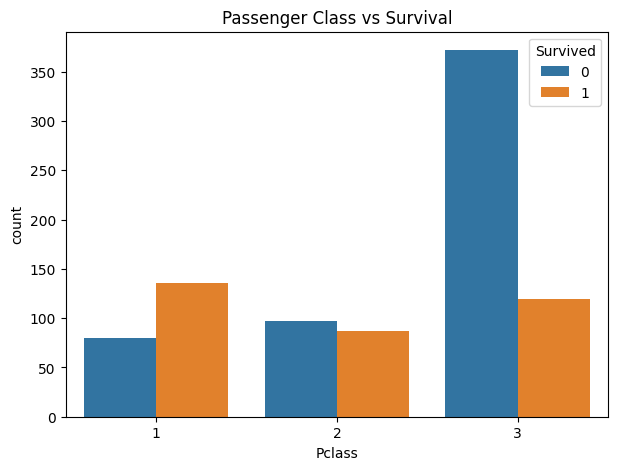

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=train,
    x="Pclass",
    hue="Survived"
)

plt.title("Passenger Class vs Survival")
plt.show()

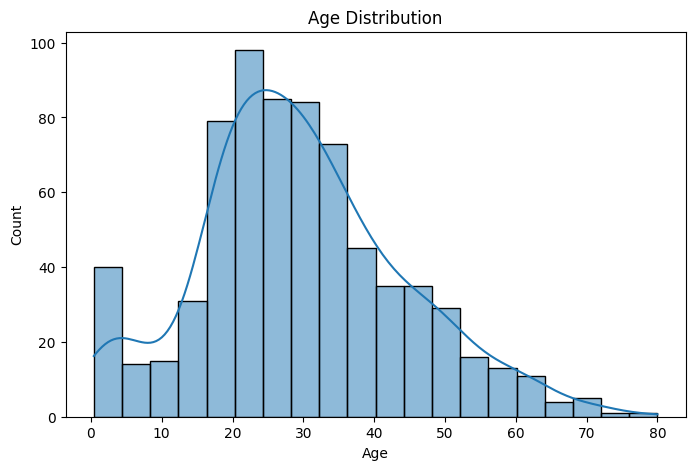

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=train,
    x="Age",
    kde=True
)

plt.title("Age Distribution")
plt.show()

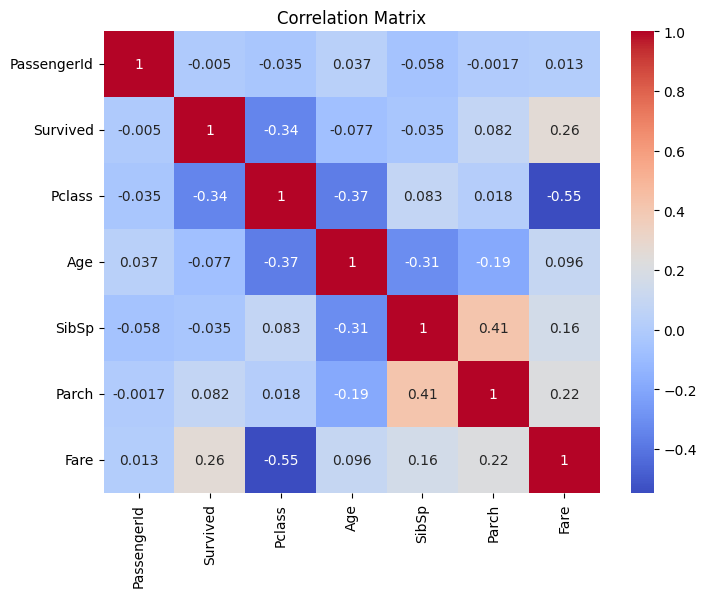

In [13]:
corr = train.select_dtypes(
    include=np.number
).corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

In [14]:
print("Missing Values")

display(
    train.isnull()
    .sum()
    .sort_values(ascending=False)
)

Missing Values


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0


In [15]:
print("Key Findings")

print("""
1. Females survive more often than males.
2. First-class passengers survive more often.
3. Age contains missing values.
4. Cabin contains many missing values.
5. Fare and Pclass appear important.
""")

Key Findings

1. Females survive more often than males.
2. First-class passengers survive more often.
3. Age contains missing values.
4. Cabin contains many missing values.
5. Fare and Pclass appear important.

